# Lista 4 - Redes Neurais Artificiais

**Disciplina:** CKP8277 - Aprendizagem Automatica  
**Periodo:** 2026.1  
**Professor:** Cesar Lincoln Cavalcante Mattos  
**Aluno:** Diego Melo do Nascimento  
**Matricula:** 603127

---

**Conteudo:**
- Questao 1: MLP para regressao -- `concrete.csv` (resistencia a compressao do concreto)
- Questao 2: MLP para classificacao -- `vehicle.csv` (silhuetas de veiculos, 4 classes)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings('ignore')
np.random.seed(42)

## Funcoes Auxiliares

In [18]:
# Pre-processamento 

def compute_mean(X):
    return np.sum(X, axis=0) / X.shape[0]

def compute_std(X):
    mu = compute_mean(X)
    return np.sqrt(np.sum((X - mu) ** 2, axis=0) / X.shape[0])

def fit_standardize(X):
    mu    = compute_mean(X)
    sigma = compute_std(X)
    sigma[sigma == 0] = 1
    return mu, sigma

def apply_standardize(X, mu, sigma):
    return (X - mu) / sigma

# Ativacoes e codificacao 

def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(float)

def softmax(z):
    e = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

def one_hot(y, num_classes):
    Y = np.zeros((len(y), num_classes))
    Y[np.arange(len(y)), y.astype(int)] = 1
    return Y

# Metricas de regressao

def mse(y, yh):
    return compute_mean((y - yh) ** 2)

def rmse(y, yh):
    return np.sqrt(mse(y, yh))

def mae(y, yh):
    return compute_mean(np.abs(y - yh))

def mre(y, yh):
    return compute_mean(np.abs((y - yh) / (y + 1e-8)))

# Metricas de classificacao 

def accuracy(y_true, y_pred):
    return compute_mean((y_true == y_pred).astype(float))

def confusion_matrix(y_true, y_pred, classes):
    n = len(classes)
    idx = {c: i for i, c in enumerate(sorted(classes))}
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[idx[int(t)], idx[int(p)]] += 1
    return cm

def precision_recall_f1_macro(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred, classes)
    prec, rec, f1 = [], [], []
    for i in range(len(classes)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        p = tp / (tp + fp + 1e-8)
        r = tp / (tp + fn + 1e-8)
        prec.append(p); rec.append(r)
        f1.append(2 * p * r / (p + r + 1e-8))
    return compute_mean(np.array(prec)), compute_mean(np.array(rec)), compute_mean(np.array(f1))

def cross_entropy_loss(y_oh, probs):
    return -compute_mean(np.sum(y_oh * np.log(probs + 1e-8), axis=1))

# Particionamento e validacao cruzada 

def kfold_split(n_samples, k=10, seed=42):
    rng = np.random.default_rng(seed)
    indices = rng.permutation(n_samples)
    folds = np.array_split(indices, k)
    splits = []
    for i in range(k):
        test_idx  = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        splits.append((train_idx, test_idx))
    return splits

def train_val_test_split(X, y, train_ratio=0.6, val_ratio=0.2, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    n_tr = int(len(X) * train_ratio)
    n_va = int(len(X) * val_ratio)
    return (X[idx[:n_tr]], X[idx[n_tr:n_tr+n_va]], X[idx[n_tr+n_va:]],
            y[idx[:n_tr]], y[idx[n_tr:n_tr+n_va]], y[idx[n_tr+n_va:]])

def evaluate_kfold(X, y, model_factory, metric_fn, k=5, normalize=True, seed=42):
    splits = kfold_split(X.shape[0], k=k, seed=seed)
    scores = []
    for train_idx, test_idx in splits:
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        if normalize:
            mu, sigma = fit_standardize(X_tr)
            X_tr = apply_standardize(X_tr, mu, sigma)
            X_te = apply_standardize(X_te, mu, sigma)
        model = model_factory()
        model.fit(X_tr, y_tr)
        scores.append(metric_fn(y_te, model.predict(X_te)))
    return np.array(scores)

# Random Search com validacao cruzada

def random_search_cv(X, y, sample_params, make_factory, metric_fn,
                     n_search=16, k=5, maximize=True, seed=42):
    rng = np.random.default_rng(seed)
    grid = [sample_params(rng) for _ in range(n_search)]
    results = []
    for i, params in enumerate(grid):
        scores = evaluate_kfold(X, y, make_factory(params), metric_fn, k=k, seed=seed)
        results.append({**params, 'score_mean': scores.mean(),
                        'score_std': scores.std(), 'fold_scores': scores})
    results.sort(key=lambda r: r['score_mean'], reverse=maximize)
    return results, results[0]

def print_ranking(results, param_keys, score_label, top=10):
    best = results[0]
    print('=' * 72)
    print('MELHOR CONFIGURACAO  (selecionada por ' + score_label + ' medio em 5-fold CV)')
    print('=' * 72)
    print('  ' + '  '.join(f'{k}={best[k]:.5f}' if isinstance(best[k], float) else f'{k}={best[k]}'
                           for k in param_keys))
    print(f'  {score_label} medio: {best["score_mean"]:.4f} +/- {best["score_std"]:.4f}')
    print('=' * 72)
    print(f'\nTop {top} de {len(results)} configuracoes:')
    header = '#   ' + ' '.join(f'{k:>9}' for k in param_keys) + f'  {score_label+" medio":>14} {"Desvio":>8}'
    print(header); print('-' * len(header))
    for rank, r in enumerate(results[:top], 1):
        row = f'{rank:<3} ' + ' '.join(f'{r[k]:>9.5f}' if isinstance(r[k], float) else f'{r[k]:>9}'
                                       for k in param_keys)
        print(row + f'  {r["score_mean"]:>14.4f} {r["score_std"]:>8.4f}')

# Graficos 
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

def plot_loss_curves(train_l, val_l, title='Curvas de Custo'):
    plt.figure(figsize=(10, 4))
    plt.plot(train_l, color=colors[0], linewidth=2, label='Treino')
    plt.plot(val_l,   color=colors[1], linewidth=2, label='Validacao')
    plt.xlabel('Epoca'); plt.ylabel('Custo'); plt.title(title)
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

def plot_search_results(results, score_label, title, ylim=None, top=15):
    sub = results[:top]
    best = results[0]
    fig, ax = plt.subplots(figsize=(13, 4.5))
    labels = [f'nh={r["n_hidden"]}\nlr={r["lr"]:.4f}' for r in sub]
    bp = ax.boxplot([r['fold_scores'] for r in sub], labels=labels, patch_artist=True)
    for i, box in enumerate(bp['boxes']):
        box.set_facecolor(colors[2] if i == 0 else colors[0])
        box.set_alpha(0.6)
    ax.set_title(f'{title}  |  Top {top} configuracoes (verde = melhor)',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel(score_label); ax.tick_params(axis='x', labelsize=7, rotation=90)
    ax.grid(True, alpha=0.3)
    if ylim: ax.set_ylim(ylim)
    plt.tight_layout(); plt.show()

def plot_regression_diagnostics(y_true, y_pred, unit='MPa', title='Diagnostico da Regressao'):
    residuos = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[0].scatter(y_true, y_pred, alpha=0.6, color=colors[0], edgecolors='white', linewidth=0.5)
    axes[0].plot(lim, lim, '--', color=colors[3], linewidth=2, label='$y = \\hat{y}$ (ideal)')
    axes[0].set_xlabel(f'Real ({unit})'); axes[0].set_ylabel(f'Predito ({unit})')
    axes[0].set_title(f'Predito vs. Real  |  RMSE = {rmse(y_true, y_pred):.2f}')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].hist(residuos, bins=30, color=colors[2], edgecolor='white', alpha=0.8)
    axes[1].axvline(0, color=colors[3], linestyle='--', linewidth=2, label='zero')
    axes[1].axvline(residuos.mean(), color=colors[1], linestyle='-', linewidth=2,
                    label=f'media = {residuos.mean():.2f}')
    axes[1].set_xlabel('Residuo (Real - Predito)'); axes[1].set_ylabel('Frequencia')
    axes[1].set_title('Distribuicao dos Residuos')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

def plot_cm(cm, classes, title, ax=None):
    show = ax is None
    if show:
        fig, ax = plt.subplots(figsize=(6, 5))
    cm_pct = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8) * 100
    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    ax.set_title(title, fontsize=10)
    ticks = list(sorted(classes))
    ax.set_xticks(range(len(ticks))); ax.set_yticks(range(len(ticks)))
    ax.set_xticklabels(ticks); ax.set_yticklabels(ticks)
    ax.set_xlabel('Predito'); ax.set_ylabel('Verdadeiro')
    for i in range(len(ticks)):
        for j in range(len(ticks)):
            color = 'white' if cm_pct[i, j] > 50 else 'black'
            ax.text(j, i, f'{cm_pct[i,j]:.1f}%\n({cm[i,j]})',
                    ha='center', va='center', color=color, fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)
    if show:
        plt.tight_layout(); plt.show()

def plot_accuracy_per_class(cm, class_names, global_acc, title='Acuracia por Classe'):
    acc_classe = cm.diagonal() / cm.sum(axis=1)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(class_names, acc_classe, color=colors[:len(class_names)],
                  edgecolor='white', linewidth=1.2)
    ax.axhline(global_acc, color=colors[3], linestyle='--', linewidth=2,
               label=f'Acuracia global = {global_acc:.3f}')
    for bar, v in zip(bars, acc_classe):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim([0, 1.1]); ax.set_ylabel('Acuracia')
    ax.set_title(title, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout(); plt.show()

## Implementacao da MLP

Rede com **1 camada oculta**, treinada com **SGD em mini-batch com momentum**.

In [19]:
class MLP:
    """MLP com 1 camada oculta (matrizes aumentadas W e M)."""

    def __init__(self, n_input, n_hidden, n_output, task='regression',
                 lr=0.01, mu=0.9, batch_size=32, epochs=200, seed=42):
        self.task       = task
        self.lr         = lr
        self.mu         = mu          # momentum
        self.batch_size = batch_size
        self.epochs     = epochs

        rng = np.random.default_rng(seed)
        # W in R^{N_H x (D+1)},  M in R^{K x (N_H+1)}  - coluna 0 = bias (init 0)
        self.W  = rng.normal(0, np.sqrt(2.0 / n_input),  (n_hidden, n_input  + 1))
        self.W[:, 0] = 0.0
        self.M  = rng.normal(0, np.sqrt(2.0 / n_hidden), (n_output, n_hidden + 1))
        self.M[:, 0] = 0.0
        # velocidades do momentum
        self.vW = np.zeros_like(self.W)
        self.vM = np.zeros_like(self.M)

    @staticmethod
    def _aug(X):
        """Acrescenta coluna de uns em x_0 (entrada aumentada)."""
        return np.hstack([np.ones((X.shape[0], 1)), X])

    def forward(self, X):
        self.X_aug = self._aug(X)                       # (N, D+1)
        self.U     = self.X_aug @ self.W.T              # (N, N_H)
        Z          = relu(self.U)                       # phi_1(U)
        self.Z_aug = self._aug(Z)                       # (N, N_H+1)
        self.R     = self.Z_aug @ self.M.T              # (N, K)
        self.O     = softmax(self.R) if self.task == 'classification' else self.R
        return self.O

    def backward(self, Y):
        N          = self.X_aug.shape[0]
        delta      = -(Y - self.O) / N                  # (N, K)
        zeta       = relu_grad(self.U) * (delta @ self.M[:, 1:])  # (N, N_H)
        gM         = delta.T @ self.Z_aug               # (K, N_H+1)
        gW         = zeta.T  @ self.X_aug               # (N_H, D+1)
        return gW, gM

    def update(self, gW, gM):
        clip = 5.0
        np.clip(gW, -clip, clip, out=gW)
        np.clip(gM, -clip, clip, out=gM)
        # Delta(t+1) = mu*Delta(t) - alpha*g;  w(t+1) = w(t) + Delta(t+1)
        self.vW = self.mu * self.vW - self.lr * gW
        self.vM = self.mu * self.vM - self.lr * gM
        self.W += self.vW
        self.M += self.vM

    def fit(self, X_tr, y_tr, X_va, y_va):
        train_l, val_l = [], []
        N = X_tr.shape[0]
        for _ in range(self.epochs):
            idx = np.random.permutation(N)
            Xs, ys = X_tr[idx], y_tr[idx]
            for s in range(0, N, self.batch_size):
                Xb, yb = Xs[s:s+self.batch_size], ys[s:s+self.batch_size]
                self.forward(Xb)
                self.update(*self.backward(yb))
            Ot = self.forward(X_tr)
            Ov = self.forward(X_va)
            if self.task == 'classification':
                train_l.append(cross_entropy_loss(y_tr, Ot))
                val_l.append(cross_entropy_loss(y_va, Ov))
            else:
                train_l.append(mse(y_tr, Ot))
                val_l.append(mse(y_va, Ov))
        return train_l, val_l

    def predict(self, X):
        O = self.forward(X)
        return O.argmax(axis=1) if self.task == 'classification' else O.ravel()

In [ ]:
class MLPRegressor:
    def __init__(self, n_hidden, lr, mu, batch_size, epochs=300, seed=42):
        self.kwargs = dict(n_hidden=n_hidden, lr=lr, mu=mu,
                           batch_size=batch_size, epochs=epochs, seed=seed)

    def fit(self, X, y):
        self.net = MLP(n_input=X.shape[1], n_output=1, task='regression', **self.kwargs)
        self.net.fit(X, y.reshape(-1, 1), X, y.reshape(-1, 1))
        return self

    def predict(self, X):
        return self.net.predict(X)


class MLPClassifier:
    def __init__(self, n_classes, n_hidden, lr, mu, batch_size, epochs=300, seed=42):
        self.n_classes = n_classes
        self.kwargs = dict(n_hidden=n_hidden, lr=lr, mu=mu,
                           batch_size=batch_size, epochs=epochs, seed=seed)

    def fit(self, X, y):
        self.net = MLP(n_input=X.shape[1], n_output=self.n_classes,
                       task='classification', **self.kwargs)
        Y = one_hot(y, self.n_classes)
        self.net.fit(X, Y, X, Y)
        return self

    def predict(self, X):
        return self.net.predict(X)

---
## Questao 1 - Regressao: Resistencia a Compressao do Concreto

Dataset: `concrete.csv` - 1029 amostras, 8 atributos, saida continua (MPa)

### Carregamento dos Dados

In [21]:
data = np.genfromtxt('data/concrete.csv', delimiter=',', skip_header=1)
X_reg = data[:, :-1]
y_reg = data[:,  -1]

print(f'Amostras: {X_reg.shape[0]} | Features: {X_reg.shape[1]}')
print(f'Saida (MPa): min={y_reg.min():.2f}  max={y_reg.max():.2f}  media={y_reg.mean():.2f}')

Amostras: 1029 | Features: 8
Saida (MPa): min=2.33  max=82.60  media=35.78


### a) Selecao de Hiperparametros via Random Search (5-Fold CV)

Os hiperparametros da MLP sao escolhidos por **busca aleatoria** avaliada com
**validacao cruzada de 5 folds**. Em cada fold a normalizacao e ajustada
**apenas no treino** e aplicada no teste (sem data leakage). A configuracao
vencedora e a de **menor RMSE medio** nos 5 folds, e sera usada no treino final (item b).
**Numero de tentativas: 100.** 
aleatorias tem ~95% de chance de cair na regiao dos 5% melhores do espaco.

MELHOR CONFIGURACAO  (selecionada por RMSE medio em 5-fold CV)
  n_hidden=128  lr=0.00166  mu=0.95000  batch_size=32
  RMSE medio: 5.0727 +/- 0.3972

Top 10 de 100 configuracoes:
#    n_hidden        lr        mu batch_size      RMSE medio   Desvio
---------------------------------------------------------------------
1         128   0.00166   0.95000        32          5.0727   0.3972
2         128   0.00076   0.90000        32          5.0774   0.3791
3         128   0.00292   0.90000        64          5.0833   0.2992
4         128   0.00099   0.90000        64          5.2270   0.3483
5         128   0.00032   0.90000        16          5.3020   0.4431
6         128   0.00039   0.90000        32          5.3280   0.2937
7          64   0.00024   0.99000        32          5.3635   0.4173
8          64   0.00198   0.90000        64          5.4163   0.3211
9         128   0.00012   0.99000        64          5.4346   0.3352
10         64   0.00181   0.50000        16          5.4676 

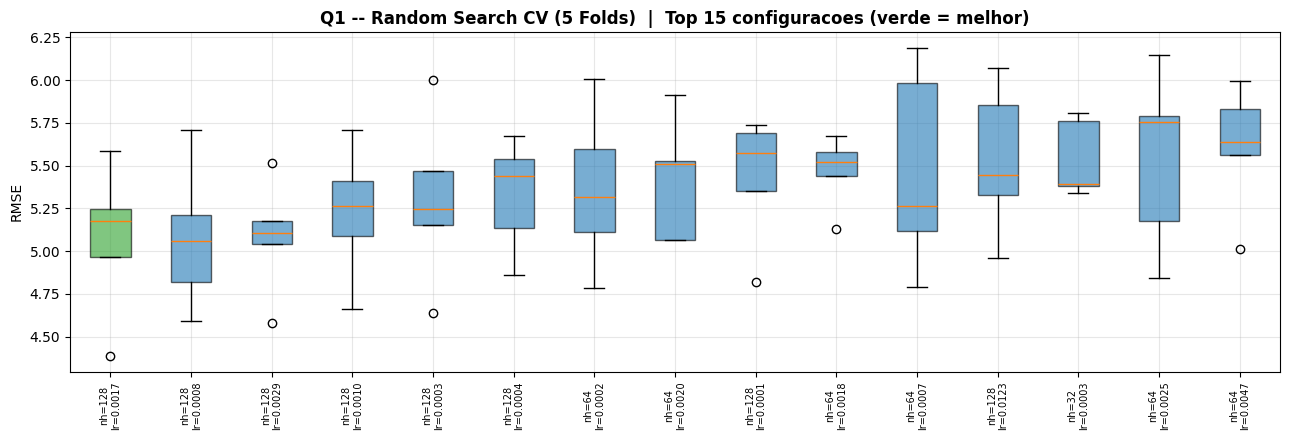

In [22]:
N_SEARCH, N_FOLDS, CV_EPOCHS = 100, 5, 150

def sample_params(rng):
    return {
        'n_hidden':   int(rng.choice([8, 16, 32, 64, 128])),
        'lr':         float(np.power(10, rng.uniform(-4, -1))),
        'mu':         float(rng.choice([0.5, 0.9, 0.95, 0.99])),
        'batch_size': int(rng.choice([16, 32, 64, 128])),
    }

results_r, best_r = random_search_cv(
    X_reg, y_reg, sample_params,
    make_factory=lambda p: (lambda: MLPRegressor(p['n_hidden'], p['lr'], p['mu'],
                                                 p['batch_size'], epochs=CV_EPOCHS)),
    metric_fn=rmse, n_search=N_SEARCH, k=N_FOLDS, maximize=False, seed=42)

print_ranking(results_r, ['n_hidden', 'lr', 'mu', 'batch_size'], 'RMSE')
plot_search_results(results_r, 'RMSE', 'Q1 -- Random Search CV (5 Folds)')

### b) Treino Final e Curvas de Custo

Com a **melhor configuracao** do random search, os dados sao divididos
aleatoriamente em **treino (60%), validacao (20%) e teste (20%)**. A normalizacao
e ajustada no treino e aplicada nos demais conjuntos. Abaixo, as curvas de custo
(MSE) de treino e validacao ao longo das epocas.

Treino: 617 | Validacao: 205 | Teste: 207
Config: n_hidden=128, lr=0.00166, mu=0.95, batch_size=32


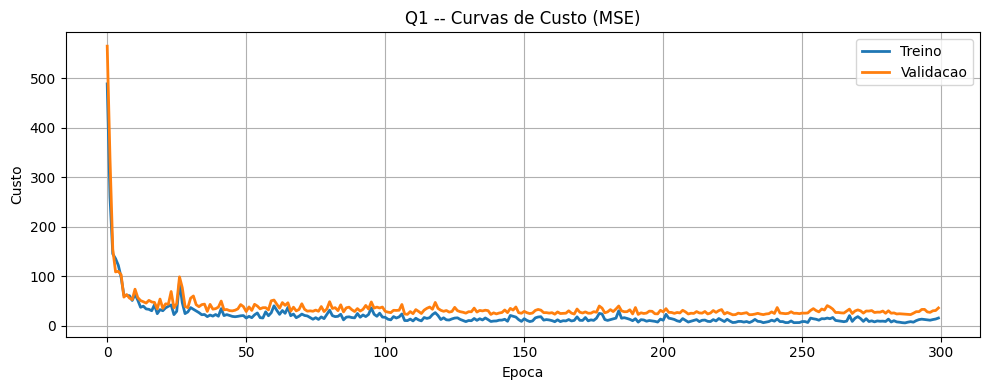

In [23]:
# divisao treino/validacao/teste (60/20/20)
X_tr, X_va, X_te, y_tr, y_va, y_te = train_val_test_split(X_reg, y_reg)
print(f'Treino: {len(X_tr)} | Validacao: {len(X_va)} | Teste: {len(X_te)}')

mu, sigma = fit_standardize(X_tr)
X_tr_n = apply_standardize(X_tr, mu, sigma)
X_va_n = apply_standardize(X_va, mu, sigma)
X_te_n = apply_standardize(X_te, mu, sigma)

# treino final com a melhor configuracao encontrada pelo random search
mlp_reg = MLP(
    n_input=X_tr_n.shape[1], n_hidden=best_r['n_hidden'], n_output=1,
    task='regression', lr=best_r['lr'], mu=best_r['mu'],
    batch_size=best_r['batch_size'], epochs=300
)
train_losses_r, val_losses_r = mlp_reg.fit(
    X_tr_n, y_tr.reshape(-1, 1),
    X_va_n, y_va.reshape(-1, 1)
)
print(f"Config: n_hidden={best_r['n_hidden']}, lr={best_r['lr']:.5f}, "
      f"mu={best_r['mu']}, batch_size={best_r['batch_size']}")

plot_loss_curves(train_losses_r, val_losses_r, title='Q1 -- Curvas de Custo (MSE)')

### c) Metricas Finais (Treino, Validacao e Teste)

Avaliacao do modelo final nas tres particoes, com as metricas pedidas:
RMSE, MAE e MRE.

In [24]:
print('=' * 55)
print(f'{"Conjunto":<12} {"RMSE":>10} {"MAE":>10} {"MRE":>10}')
print('-' * 55)
for name, Xn, yn in [('Treino', X_tr_n, y_tr), ('Validacao', X_va_n, y_va), ('Teste', X_te_n, y_te)]:
    yh = mlp_reg.predict(Xn)
    print(f'{name:<12} {rmse(yn, yh):>10.4f} {mae(yn, yh):>10.4f} {mre(yn, yh):>10.4f}')
print('=' * 55)

Conjunto           RMSE        MAE        MRE
-------------------------------------------------------
Treino           3.9569     2.8480     0.0936
Validacao        6.0032     4.4010     0.1403
Teste            5.9061     4.2263     0.1294


#### Diagnostico da Regressao

Dois graficos essenciais para avaliar um modelo de regressao:
- **Predito vs. Real:** quanto mais proximo da diagonal $y = \hat{y}$, melhor o ajuste.
- **Distribuicao dos residuos** ($y - \hat{y}$): idealmente centrada em zero e simetrica.

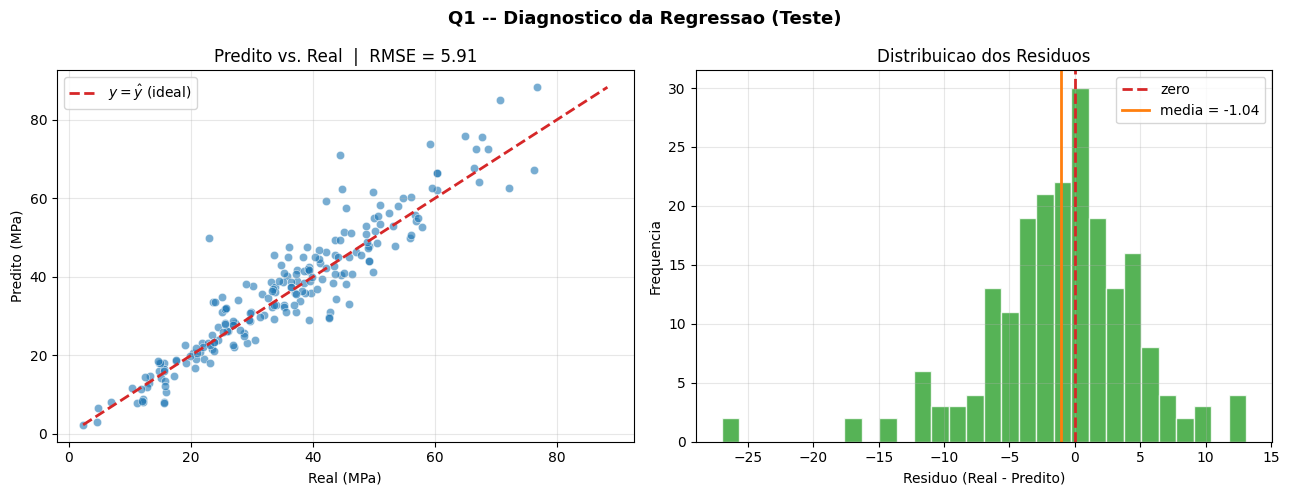

In [25]:
y_pred_te = mlp_reg.predict(X_te_n)
plot_regression_diagnostics(y_te, y_pred_te, unit='MPa',
                            title='Q1 -- Diagnostico da Regressao (Teste)')

---
## Questao 2 -- Classificacao: Silhuetas de Veiculos

Dataset: `vehicle.csv` - 846 amostras, 18 atributos, 4 classes (bus=0, opel=1, saab=2, van=3)

### Carregamento dos Dados

In [26]:
data_v = np.genfromtxt('data/vehicle.csv', delimiter=',')
X_clf  = data_v[:, :-1]
y_clf  = data_v[:,  -1].astype(int)

CLASS_NAMES = ['bus', 'opel', 'saab', 'van']
N_CLASSES   = 4

print(f'Amostras: {X_clf.shape[0]} | Features: {X_clf.shape[1]}')
values, counts = np.unique(y_clf, return_counts=True)
print('Distribuicao de classes:')
for v, c in zip(values, counts):
    print(f'  {CLASS_NAMES[v]:>5}: {c} amostras ({100*c/len(y_clf):.1f}%)')

Amostras: 846 | Features: 18
Distribuicao de classes:
    bus: 218 amostras (25.8%)
   opel: 212 amostras (25.1%)
   saab: 217 amostras (25.7%)
    van: 199 amostras (23.5%)


### a) Selecao de Hiperparametros via Random Search (5-Fold CV)

Mesma estrategia e mesmo espaco de busca fundamentado da Questao 1 (reaproveitamos
`sample_params` e `random_search_cv`). A diferenca e a metrica de selecao:
aqui a configuracao vencedora e a de **maior acuracia media** nos 5 folds.
**Numero de tentativas: 100**

In [ ]:
results_c, best_c = random_search_cv(
    X_clf, y_clf, sample_params,
    make_factory=lambda p: (lambda: MLPClassifier(N_CLASSES, p['n_hidden'], p['lr'],
                                                  p['mu'], p['batch_size'], epochs=CV_EPOCHS)),
    metric_fn=accuracy, n_search=N_SEARCH, k=N_FOLDS, maximize=True, seed=42)

print_ranking(results_c, ['n_hidden', 'lr', 'mu', 'batch_size'], 'Acuracia')
plot_search_results(results_c, 'Acuracia', 'Q2 - Random Search CV (5 Folds)', ylim=[0, 1.05])

### b) Treino Final e Curvas de Custo

Com a **melhor configuracao** do random search, os dados sao divididos em
**treino (60%), validacao (20%) e teste (20%)**. Abaixo, as curvas de custo
(cross-entropy) de treino e validacao ao longo das epocas.

Treino: 507 | Validacao: 169 | Teste: 170
Config: n_hidden=64, lr=0.00116, mu=0.99, batch_size=64


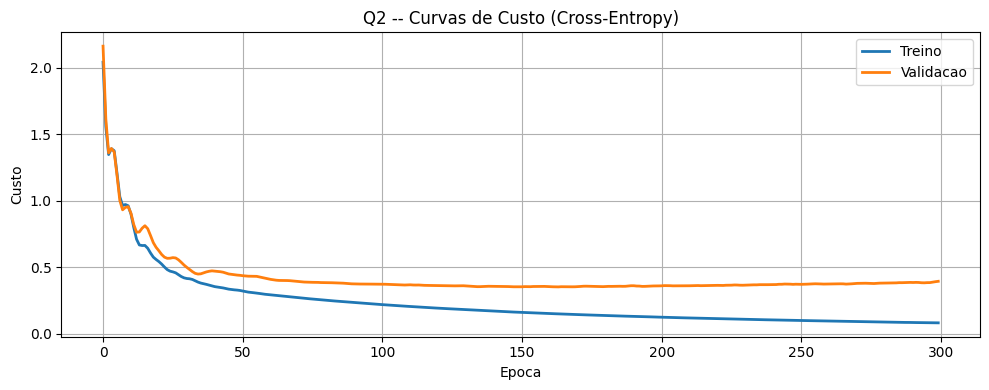

In [ ]:
# divisao treino/validacao/teste (60/20/20)
X_tr2, X_va2, X_te2, y_tr2, y_va2, y_te2 = train_val_test_split(X_clf, y_clf)
print(f'Treino: {len(X_tr2)} | Validacao: {len(X_va2)} | Teste: {len(X_te2)}')

mu2, sigma2 = fit_standardize(X_tr2)
X_tr2_n = apply_standardize(X_tr2, mu2, sigma2)
X_va2_n = apply_standardize(X_va2, mu2, sigma2)
X_te2_n = apply_standardize(X_te2, mu2, sigma2)

y_tr2_oh = one_hot(y_tr2, N_CLASSES)
y_va2_oh = one_hot(y_va2, N_CLASSES)

# treino final com a melhor configuracao encontrada pelo random search
mlp_clf = MLP(
    n_input=X_tr2_n.shape[1], n_hidden=best_c['n_hidden'], n_output=N_CLASSES,
    task='classification', lr=best_c['lr'], mu=best_c['mu'],
    batch_size=best_c['batch_size'], epochs=300
)
train_losses_c, val_losses_c = mlp_clf.fit(
    X_tr2_n, y_tr2_oh,
    X_va2_n, y_va2_oh
)
print(f"Config: n_hidden={best_c['n_hidden']}, lr={best_c['lr']:.5f}, "
      f"mu={best_c['mu']}, batch_size={best_c['batch_size']}")

plot_loss_curves(train_losses_c, val_losses_c, title='Q2 -- Curvas de Custo (Cross-Entropy)')

### c) Metricas Finais e Matriz de Confusao

Avaliacao do modelo final nas tres particoes (acuracia, precisao, revocacao e
F1 macro) e matriz de confusao no conjunto de teste.

In [ ]:
print('=' * 67)
print(f'{"Conjunto":<12} {"Acuracia":>10} {"Precisao":>10} {"Revocacao":>10} {"F1":>10}')
print('-' * 67)
for name, Xn, yn in [('Treino', X_tr2_n, y_tr2), ('Validacao', X_va2_n, y_va2), ('Teste', X_te2_n, y_te2)]:
    yh = mlp_clf.predict(Xn)
    acc = accuracy(yn, yh)
    prec, rec, f1 = precision_recall_f1_macro(yn, yh, list(range(N_CLASSES)))
    print(f'{name:<12} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}')
print('=' * 67)

Conjunto       Acuracia   Precisao  Revocacao         F1
-------------------------------------------------------------------
Treino           0.9803     0.9796     0.9801     0.9798
Validacao        0.8462     0.8545     0.8650     0.8571
Teste            0.7647     0.7731     0.7707     0.7595


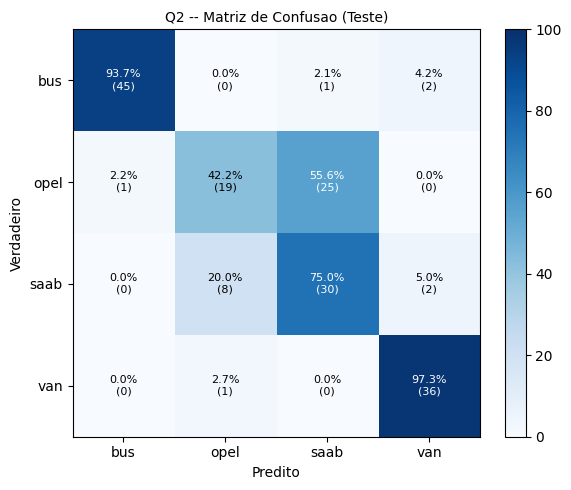

In [ ]:
y_hat_te = mlp_clf.predict(X_te2_n)
cm = confusion_matrix(y_te2, y_hat_te, list(range(N_CLASSES)))
plot_cm(cm, CLASS_NAMES, title='Q2 - Matriz de Confusao (Teste)')

#### Desempenho por Classe


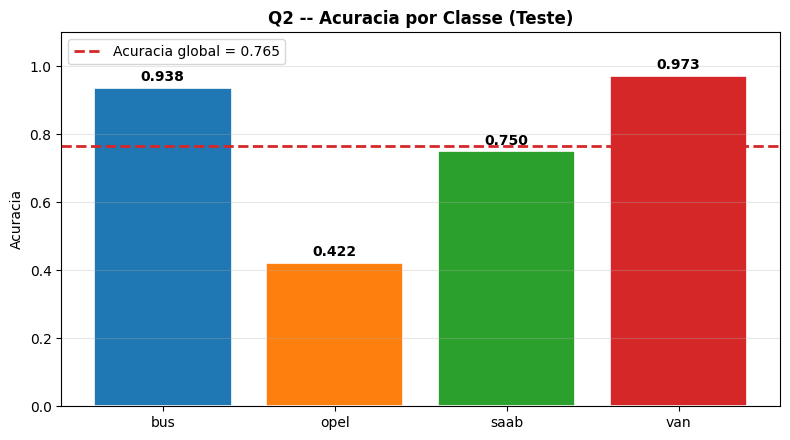

In [ ]:
plot_accuracy_per_class(cm, CLASS_NAMES, accuracy(y_te2, y_hat_te),
                        title='Q2 -- Acuracia por Classe (Teste)')